<a href="https://colab.research.google.com/github/Gr1lledChee5e/TimeSeriesForcastingPortfolio/blob/main/Exponential_Smoothing_ETS_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Packages

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.deterministic import DeterministicProcess


# Delete some of these
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR # Vector Autoregression
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import boxcox_normmax
from statsmodels.stats.diagnostic import acorr_ljungbox

# Exponential Smoothing (ETS) Models:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel


In [ ]:
#!pip install pmdarima
#from pmdarima import auto_arima

ModuleNotFoundError: No module named 'pmdarima'

In [ ]:
# Try several combos
cands = [
    dict(error="add", trend=None,  seasonal="add"),
    dict(error="add", trend="add", seasonal="add"),
    dict(error="add", trend="add", seasonal="mul"),
    dict(error="add", trend="add", seasonal="add", damped_trend=True),
]

best = None
for spec in cands:
    mod = ETSModel(y, seasonal_periods=m, **spec)
    fit = mod.fit()
    score = fit.aic
    best = (score, spec, fit) if best is None or score < best[0] else best

print("Best AIC:", best[0], "Spec:", best[1])

# Helper Functions

## accuracy

In [ ]:
def accuracy(y_observed, y_forecast):
  mae = np.mean(np.abs(y_observed - y_forecast))
  rmse = np.sqrt(np.mean((y_observed - y_forecast)**2))
  mape = np.mean(np.abs((y_observed - y_forecast) / y_observed)) * 100
  print(f'''
    MAE: {mae}
    RMSE: {rmse}
    MAPE: {mape}
  ''')

## acf_plots

In [ ]:
def acf_plots(y, lags=20, pacf_method="ywm"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    y = y.dropna()
    plot_acf(y, lags=lags, ax=axes[0])
    plot_pacf(y, lags=lags,  method=pacf_method, ax=axes[1])
    axes[0].set_title("ACF")
    axes[1].set_title("PACF")
    axes[0].set_xlim((0, lags))
    axes[1].set_xlim((0, lags))
    plt.tight_layout()
    return fig.show()

## eacf_plot

Extended Autocorrelation Function plot. Use this matrix of "x" and "o" to identify suitable values for p and q when both AR and MA terms are in your model.

In [ ]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.stattools import acf

def eacf_plot(y, max_p=4, max_q=4):
    y = y.dropna()
    y = np.asarray(y)
    n = len(y)
    crit = 2 / np.sqrt(n)  # approx 95% CI

    table = np.empty((max_p + 1, max_q + 1), dtype=object)

    for p in range(max_p + 1):
        if p == 0:
            resid = y - y.mean()
        else:
            ar = AutoReg(y, lags=p, old_names=False).fit()
            resid = ar.resid

        r = acf(resid, nlags=max_q, fft=False)

        for q in range(max_q + 1):
            table[p, q] = "o" if abs(r[q]) < crit else "x"

    return table

## lb_plot

Ljung-Box P-Values

Used to check residuals for remaining autocorrelation. Plot returns p-values for testing for autocorrelation up to each lag. We want to see high p-values, which would indicate that there is no remaining autocorrelation in the series (because we captured it in our model).



In [ ]:
def lb_plot(model_fit):
  results = acorr_ljungbox(model_fit.resid)
  lags = results.index
  plt.figure(figsize=(12,6))
  plt.scatter(x=lags, y=results['lb_pvalue'])
  plt.axhline(y=0.05, color='red', linestyle='--')
  plt.ylim(0, 1)
  plt.show()

## Generic TS CV Function

In [ ]:
def time_series_cv(
    y: pd.Series,
    h: int=1,
    initial: int=24,
    step: int=1,
    forecast_function: callable=None
):

    n = len(y)

    rows = []
    fold = 0

    for train_end in range(initial, n - h + 1, step):
        fold += 1
        y_train = y.iloc[:train_end]
        y_test  = y.iloc[train_end:train_end + h]

        # Forecast function should return y_hat only
        y_hat = forecast_function(y_train, h)

        # Align with actual y_test (should match if freq is consistent)
        y_hat = y_hat.reindex(y_test.index)
        fold_df = pd.DataFrame({
            "fold": fold,
            "cutoff": y_train.index[-1],
            "h": np.arange(1, h + 1),
            "y": y_test.values,
            "y_hat": y_hat.values
        }, index=y_test.index)

        rows.append(fold_df)

    cv_df = pd.concat(rows).sort_index()

    # Overall metrics
    err = cv_df["y"] - cv_df["y_hat"]
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))

    denom = np.where(cv_df["y"].values == 0, np.nan, np.abs(cv_df["y"].values))
    mape = float(np.nanmean(np.abs(err.values) / denom) * 100)

    metrics = {"MAE": mae, "RMSE": rmse, "MAPE%": mape}
    return metrics

# Section I - ETS

### SPY Index

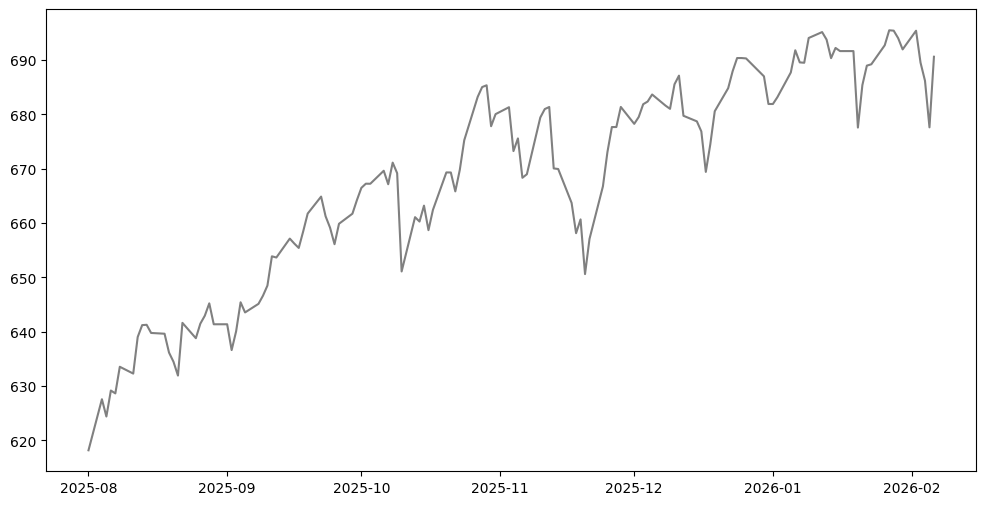

In [ ]:
# SP500 Intro
sp500 = pd.read_csv('https://dxl-datasets.s3.us-east-1.amazonaws.com/mas640/misc/sp500.csv')
sp500['day'] = pd.to_datetime(sp500['day'])
sp500 = sp500.set_index('day')
y = sp500['SPY'].asfreq('B').ffill()

plt.figure(figsize=(12, 6))
plt.plot(y, color='grey')
plt.show()


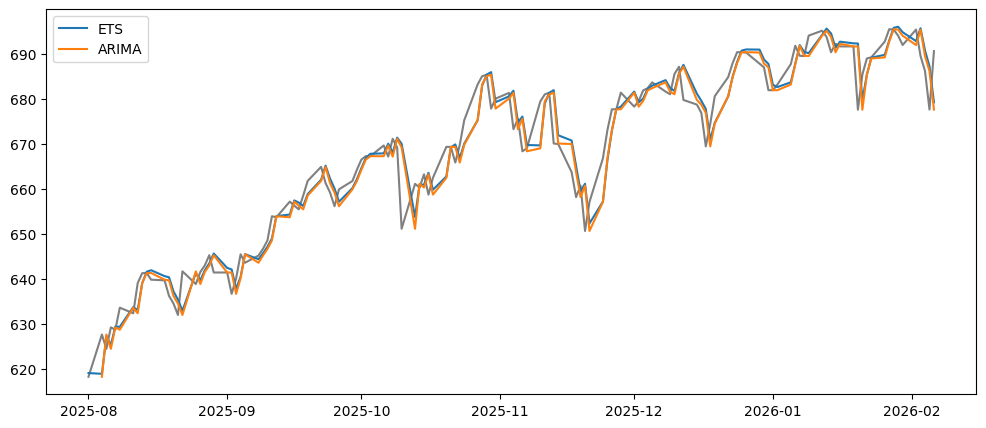

In [ ]:
m_ets = ETSModel(y, error='add', trend='add', seasonal=None).fit()
m_arima = ARIMA(y, order=(0, 1, 0)).fit()

plt.figure(figsize=(12,5))
plt.plot(y, color='grey')
plt.plot(m_ets.fittedvalues, label='ETS')
plt.plot(m_arima.fittedvalues[1:], label='ARIMA')
plt.legend()
plt.show()

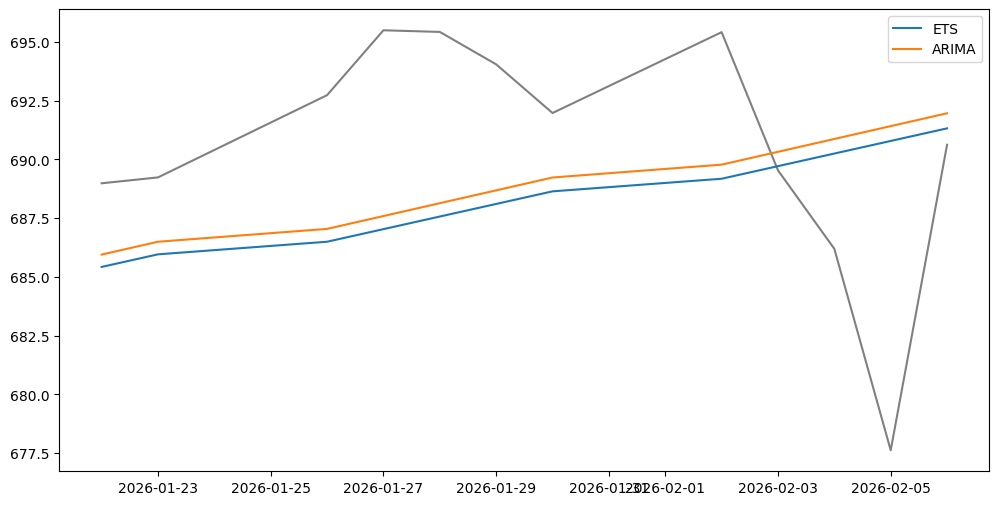

In [ ]:
y_train = y.iloc[:-12]
y_test = y.iloc[-12:]

fc_ets = ETSModel(y_train, error='add', trend='add', seasonal=None).fit().forecast(12)
fc_arima = ARIMA(y_train, order=(0, 1, 0), trend='t').fit().forecast(12)

plt.figure(figsize=(12,6))
plt.plot(y_test, color='grey')
plt.plot(fc_ets, label='ETS')
plt.plot(fc_arima, label='ARIMA')
plt.legend()
plt.show()

In [ ]:
def ets_forecast(y_train, h):
  y_hat = ETSModel(y_train, error='add', trend='add', seasonal=None).fit().forecast(h)
  return y_hat

def arima_forecast(y_train, h):
  y_hat = ARIMA(y_train, order=(0, 1, 0), trend='t').fit().forecast(h)
  return y_hat

print(time_series_cv(y, h=5, initial=30, step=1, forecast_function=ets_forecast))
print(time_series_cv(y, h=5, initial=30, step=1, forecast_function=arima_forecast))

{'MAE': 6.011682392472686, 'RMSE': 8.132038366696845, 'MAPE%': 0.8917469668766286}
{'MAE': 6.017983877758728, 'RMSE': 8.14339774156198, 'MAPE%': 0.8928121276004212}


## Supreme Court Data

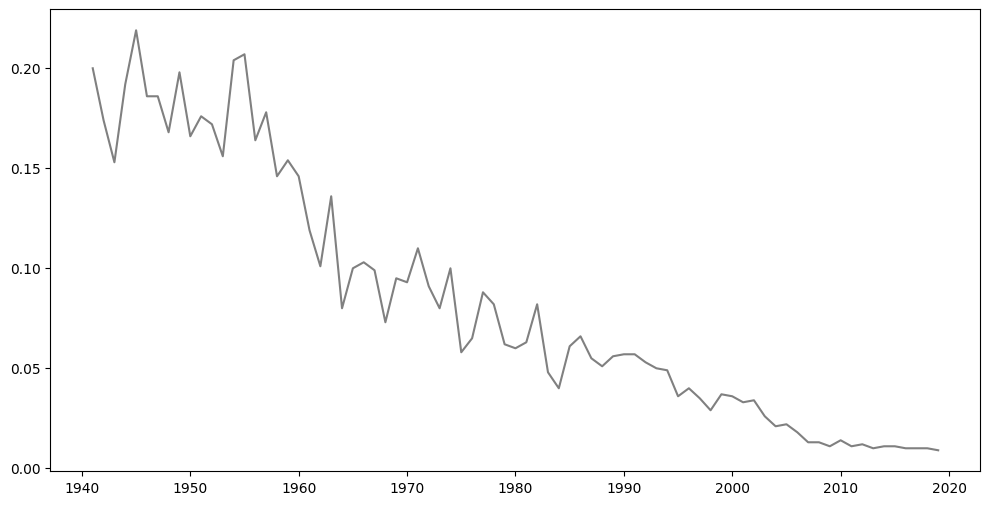

In [ ]:
# Supreme Court Data
sc = pd.read_csv('https://dxl-datasets.s3.us-east-1.amazonaws.com/mas640/misc/supreme_court.csv')
sc['year'] = pd.to_datetime(sc['year'])
sc = sc.set_index('year')
y = sc['pct_cases'].asfreq('YS')

plt.figure(figsize=(12, 6))
plt.plot(y, color='grey')
plt.show()

In [ ]:
m_ets_m = ETSModel(y, error='mul', trend='mul', seasonal=None).fit()
m_ets_a = ETSModel(y, error='add', trend='add', seasonal=None).fit()
m_ets_ad = ETSModel(y, error='mul', trend='add', seasonal=None, damped_trend=True).fit()

In [ ]:
def ets_1(y_train, h):
  y_hat = ETSModel(y_train, error='mul', trend='add', seasonal=None, damped_trend=True).fit().forecast(h)
  return y_hat

def ets_2(y_train, h):
  y_hat = ETSModel(y_train, error='mul', trend='add', seasonal=None, damped_trend=False).fit().forecast(h)
  return y_hat

In [ ]:
print(time_series_cv(y, h=5, initial=30, step=1, forecast_function=ets_1))
print(time_series_cv(y, h=5, initial=30, step=1, forecast_function=ets_2))

{'MAE': 0.007866095409450588, 'RMSE': 0.010018613587566866, 'MAPE%': 23.664216282884183}
{'MAE': 0.008389526183470207, 'RMSE': 0.010952943215369656, 'MAPE%': 25.221338906323343}


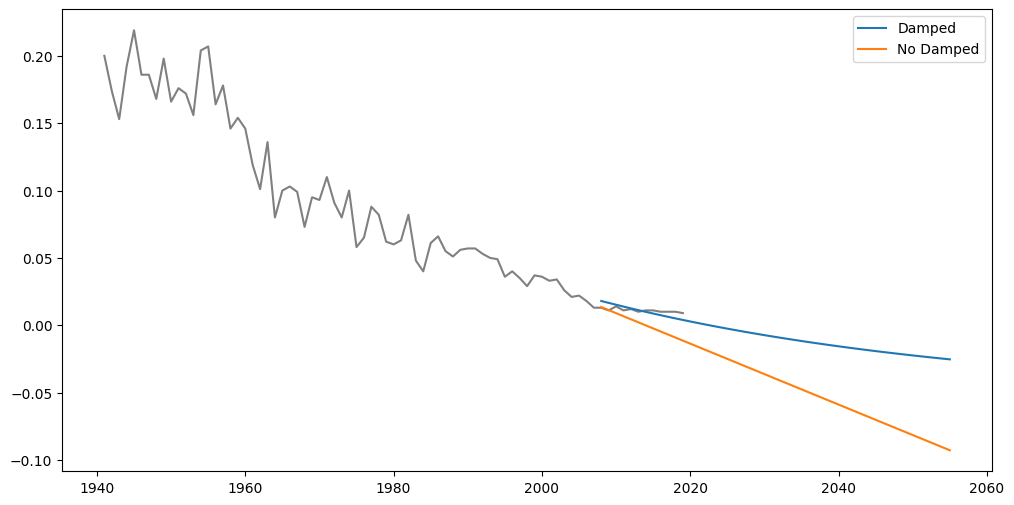

In [ ]:
y_train = y.iloc[:-12]
y_test = y.iloc[-12:]

fc_ets_1 = ETSModel(y_train, error='mul', trend='add', seasonal=None, damped_trend=True).fit().forecast(48)
fc_ets_2 = ETSModel(y_train, error='mul', trend='add', seasonal=None, damped_trend=False).fit().forecast(48)

plt.figure(figsize=(12,6))
plt.plot(y, color='grey')
plt.plot(fc_ets_1, label='Damped')
plt.plot(fc_ets_2, label='No Damped')
plt.legend()
plt.show()

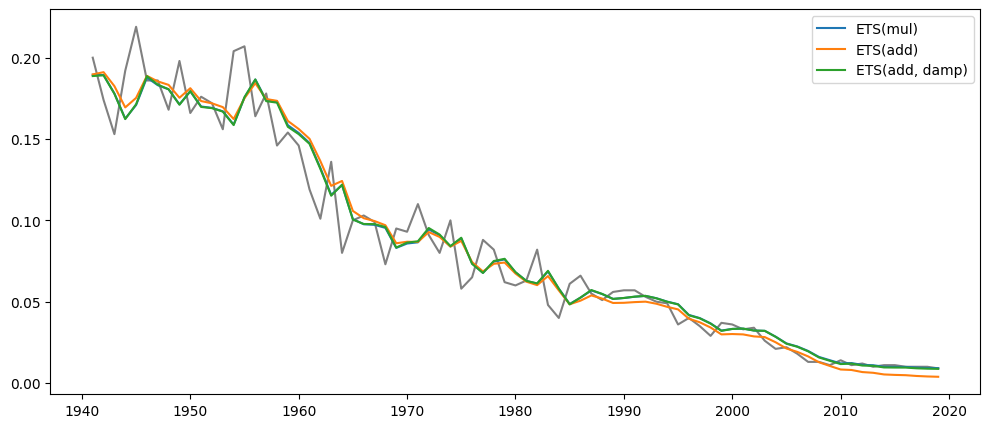

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(y, color='grey')
plt.plot(m_ets_m.fittedvalues, label='ETS(mul)')
plt.plot(m_ets_a.fittedvalues, label='ETS(add)')
plt.plot(m_ets_ad.fittedvalues, label='ETS(add, damp)')
plt.legend()
plt.show()

## Trade Data

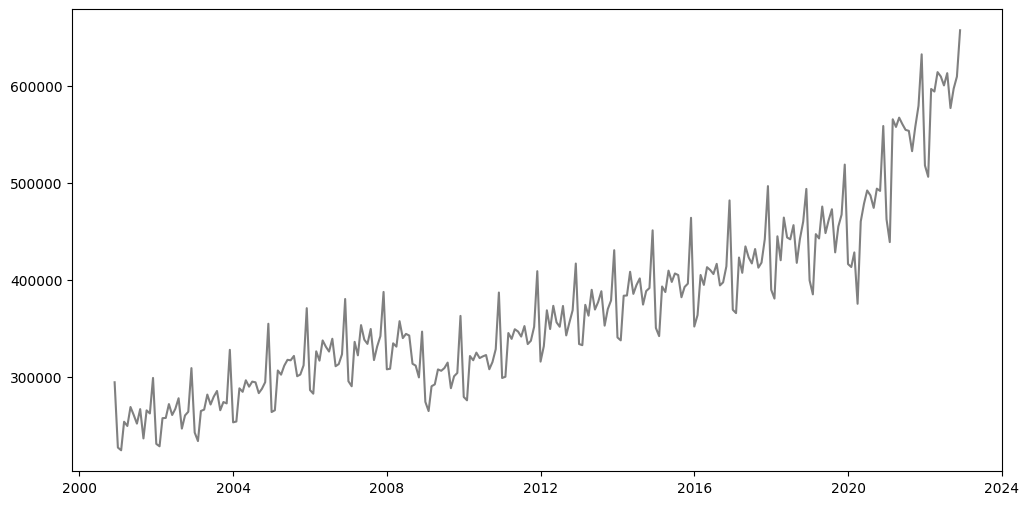

In [ ]:
fed_data = pd.read_csv('https://dxl-datasets.s3.amazonaws.com/data/fed_data.csv')
fed_data['date'] = pd.to_datetime(fed_data['date'])
fed_data = fed_data.set_index('date')
y = fed_data['trade'].asfreq('MS')

plt.figure(figsize=(12, 6))
plt.plot(y, color='grey')
plt.show()

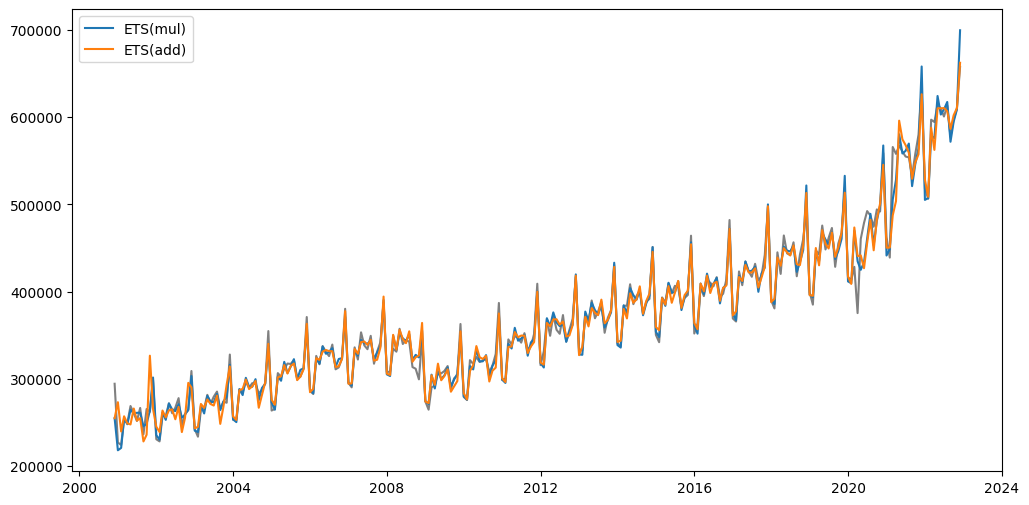

In [ ]:
m_ets1 = ETSModel(y, error='mul', trend='add', seasonal='mul', seasonal_periods=12).fit()
m_ets2 = ETSModel(y, error='add', trend='add', seasonal='add', seasonal_periods=12).fit()

plt.figure(figsize=(12,6))
plt.plot(y, color='grey')
plt.plot(m_ets1.fittedvalues, label='ETS(mul)')
plt.plot(m_ets2.fittedvalues, label='ETS(add)')
plt.legend()
plt.show()

In [ ]:
y_train = y.iloc[:-24]
y_test = y.iloc[-24:]

fc_ets1 = ETSModel(y_train, error='mul', trend='add', seasonal='mul', seasonal_periods=12).fit().forecast(24)
fc_ets2 = ETSModel(y_train, error='add', trend='add', seasonal='add', seasonal_periods=12).fit().forecast(24)

print(accuracy(y_test, fc_ets1))
print(accuracy(y_test, fc_ets2))


    MAE: 70225.86561254085
    RMSE: 74256.86206175116
    MAPE: 12.118556444285126
  
None

    MAE: 66689.67139282876
    RMSE: 73762.28641028306
    MAPE: 11.457968734841408
  
None


In [ ]:
def ets1(y_train, h):
  y_hat = ETSModel(y_train, error='mul', trend='add', seasonal='mul', seasonal_periods=12).fit().forecast(h)
  return y_hat

def ets2(y_train, h):
  y_hat = ETSModel(y_train, error='add', trend='add', seasonal='add', seasonal_periods=12).fit().forecast(h)
  return y_hat

print(time_series_cv(y, h=12, initial=120, step=5, forecast_function=ets1))
print(time_series_cv(y, h=12, initial=120, step=5, forecast_function=ets2))

{'MAE': 12332.137506449031, 'RMSE': 20440.428445922025, 'MAPE%': 2.7166951455341475}
{'MAE': 14833.078033129257, 'RMSE': 24104.87520438874, 'MAPE%': 3.2478590571313193}


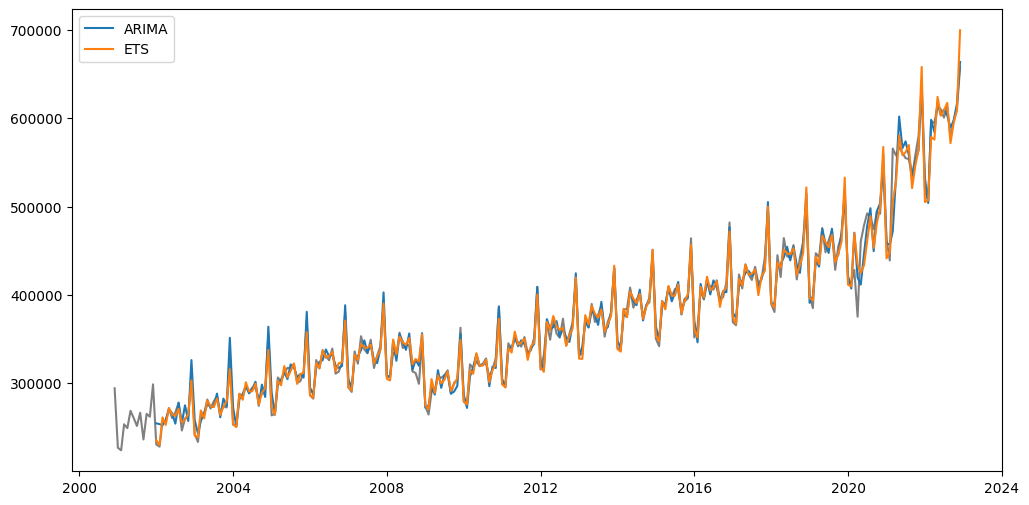

In [ ]:
# arima
m_arima = ARIMA(y, order=(0, 1, 2), seasonal_order=(0, 1, 2, 12)).fit()
m_ets = ETSModel(y, error='mul', trend='add', seasonal='mul', seasonal_periods=12).fit()


plt.figure(figsize=(12, 6))
plt.plot(y, color='grey')
plt.plot(m_arima.fittedvalues[13:], label='ARIMA')
plt.plot(m_ets.fittedvalues[13:], label='ETS')
plt.legend()
plt.show()

In [ ]:
y_train = y.iloc[:-24]
y_test = y.iloc[-24:]

fc_ets = ETSModel(y_train, error='mul', trend='add', seasonal='mul', seasonal_periods=12).fit().forecast(24)
fc_arima = ARIMA(y_train, order=(0, 1, 2), seasonal_order=(0, 1, 2, 12)).fit().forecast(24)

print(accuracy(y_test, fc_ets))
print(accuracy(y_test, fc_arima))


    MAE: 70225.86561254085
    RMSE: 74256.86206175116
    MAPE: 12.118556444285126
  
None

    MAE: 50917.76769924542
    RMSE: 58053.98057833907
    MAPE: 8.77963573273162
  
None


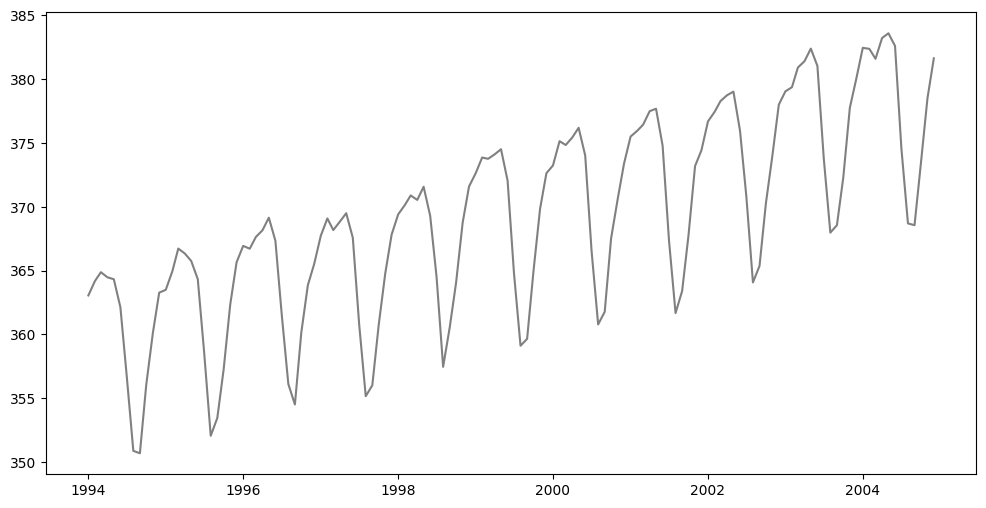

In [ ]:
co2 = pd.read_csv('https://dxl-datasets.s3.us-east-1.amazonaws.com/mas640/tsa/co2.csv')
co2['date'] = pd.to_datetime(co2['date'])
co2 = co2.set_index('date')
y = co2['co2'].asfreq('MS')

plt.figure(figsize=(12,6))
plt.plot(y, color='grey')
plt.show()

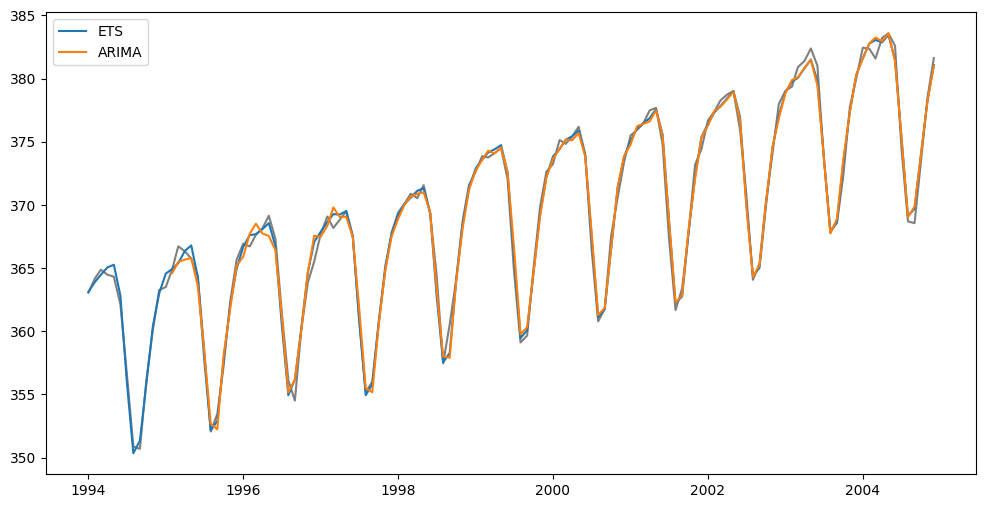

In [ ]:
# Fit
m_ets = ETSModel(y, error='add', trend='add', seasonal='add', seasonal_periods=12).fit()
m_arima = ARIMA(y, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit()

plt.figure(figsize=(12,6))
plt.plot(y, color='grey')
plt.plot(m_ets.fittedvalues, label='ETS')
plt.plot(m_arima.fittedvalues[13:], label='ARIMA')
plt.legend()
plt.show()

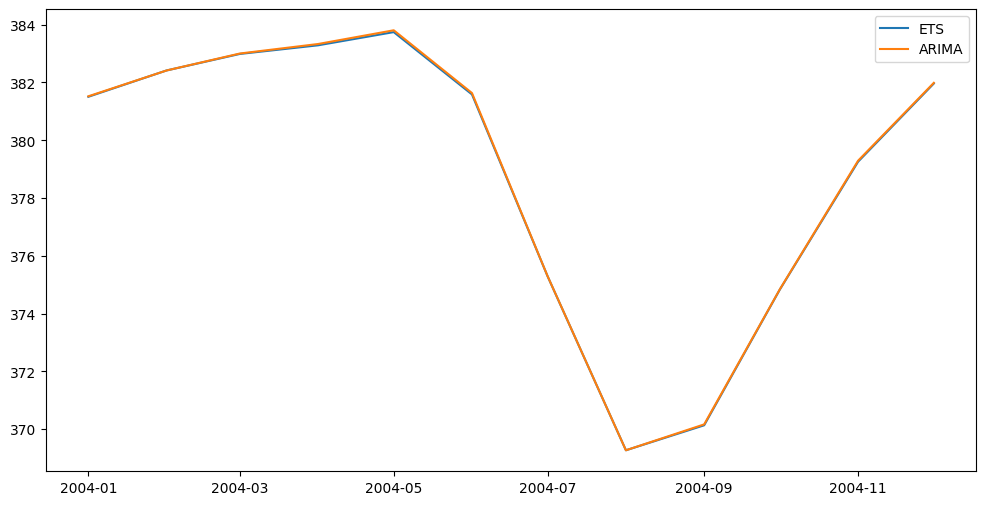

In [ ]:
y_train = y.iloc[:-12]
y_test = y.iloc[-12:]

m_ets = ETSModel(y_train, error='add', trend='add', seasonal='add', seasonal_periods=12).fit()
m_arima = ARIMA(y_train, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit()

fc_ets = m_ets.forecast(12)
fc_arima = m_arima.forecast(12)

plt.figure(figsize=(12,6))
#plt.plot(y_test, color='grey')
plt.plot(fc_ets, label='ETS')
plt.plot(fc_arima, label='ARIMA')
plt.legend()
plt.show()

In [ ]:
pd.DataFrame({'ets': fc_ets, 'arima': fc_arima})

,ets,arima
2004-01-01,381.505889,381.522759
2004-02-01,382.416966,382.416200
2004-03-01,382.987945,383.002665
2004-04-01,383.286921,383.331899
2004-05-01,383.743880,383.807279
2004-06-01,381.586824,381.634971
2004-07-01,375.285798,375.289379
2004-08-01,369.270857,369.271318
2004-09-01,370.135885,370.166889
2004-10-01,374.835814,374.845542


### Deciding ETS Model

ETS model -> Exponential Smoothing of:
+ (E) rror
+ (T) rend
+ (S) eason


```python
ETSModel(y,
         error="...",       # add, mul
         trend="...",       # add, mul, None
         seasonal="...",    # add, mul, None
         seasonal_periods=...,
         damped_trend = ... # True/False
)
```

| Component  | ADDITIVE when… | MULTIPLICATIVE when… | None when… |
| ------------------- | -------------------------------------------------- | --------------------------------------------------------------------- | ---------------------------------- |
| **Error (E)**       | "Noise" roughly constant   | Noise increases/decreases over time | Never “none” — error always exists! |
| **Trend (T)**  | Linear Trend | Growth/decline proportional to level (exponential trend) | No trend |
| **Seasonality (S)** | Seasonal swings roughly constant in size | Seasonal swings proportional to level | No seasonality |



### Pick A Model!

In [ ]:
# Series 1
co2 = pd.read_csv('https://dxl-datasets.s3.us-east-1.amazonaws.com/mas640/tsa/co2.csv')
co2['date'] = pd.to_datetime(co2['date'])
co2 = co2.set_index('date')
y = co2['co2'].asfreq('MS')

plt.figure(figsize=(12,6))
plt.plot(y, color='grey')
plt.show()

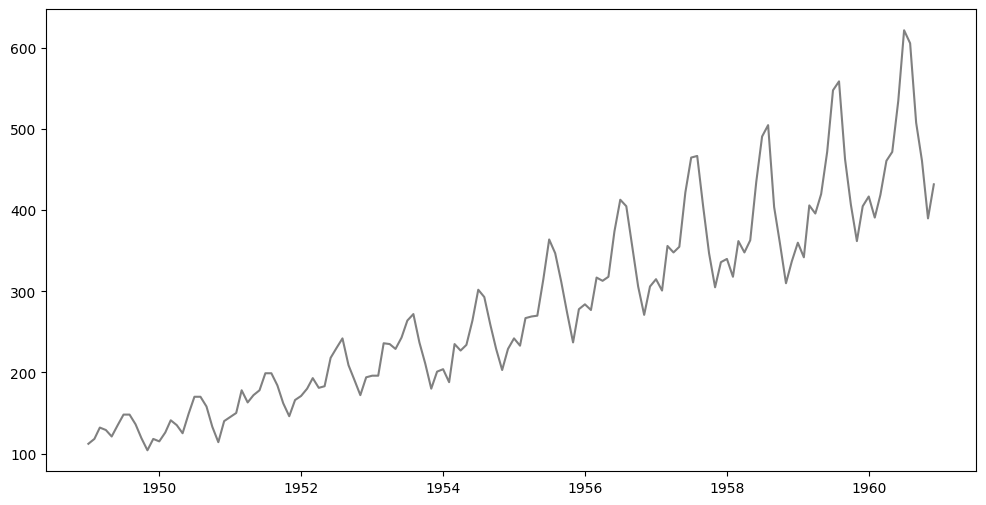

In [ ]:
# Series 2
airpassengers = pd.read_csv('https://dxl-datasets.s3.us-east-1.amazonaws.com/mas640/fppy/AirPassengers.csv')
airpassengers['ds'] = pd.to_datetime(airpassengers['ds'])
airpassengers = airpassengers.set_index('ds')
y = airpassengers['y'].asfreq('MS')

plt.figure(figsize=(12, 6))
plt.plot(y, color='grey')
plt.show()

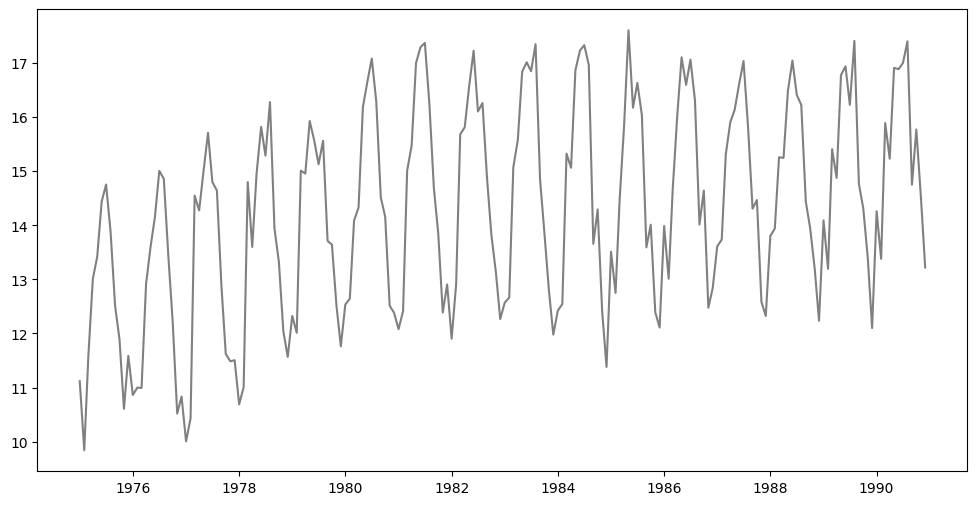

In [ ]:
# Series 3
sales = pd.read_csv('https://dxl-datasets.s3.us-east-1.amazonaws.com/mas640/tsa/beersales.csv')
sales['date'] = pd.to_datetime(sales['date'])
sales = sales.set_index('date')
y = sales['beersales'].asfreq('MS')

plt.figure(figsize=(12, 6))
plt.plot(y, color='grey')
plt.show()

In [ ]:
m1 = ETSModel(y, error='add', trend='add', seasonal='add', seasonal_periods=12).fit()
m2 = ETSModel(y, error='add', trend='add', seasonal='add', seasonal_periods=12, damped_trend=True).fit()

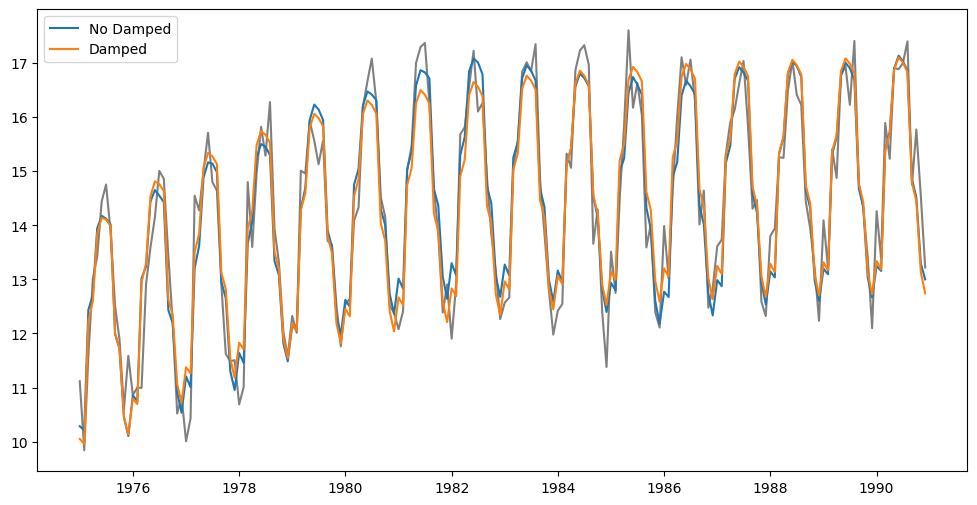

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(y, color='grey')
plt.plot(m1.fittedvalues, label='No Damped')
plt.plot(m2.fittedvalues, label='Damped')
plt.legend()
plt.show()

In [ ]:
def ets1(y_train, h):
  y_hat = ETSModel(y_train, error='add', trend='add', seasonal='add', seasonal_periods=12).fit().forecast(h)
  return y_hat

def ets2(y_train, h):
  y_hat = ETSModel(y_train, error='add', trend='add', seasonal='add', seasonal_periods=12, damped_trend=True).fit().forecast(h)
  return y_hat

print(time_series_cv(y, h=4, initial=36, step=4, forecast_function=ets1))
print(time_series_cv(y, h=4, initial=36, step=4, forecast_function=ets2))

{'MAE': 0.5009155274935313, 'RMSE': 0.6129371887112329, 'MAPE%': 3.520486241799018}
{'MAE': 0.48371204027555137, 'RMSE': 0.6033669536647961, 'MAPE%': 3.3633630141649142}



    MAE: 0.5232394092078749
    RMSE: 0.6759732277152736
    MAPE: 3.46161607016655
  
None

    MAE: 0.6898403009221595
    RMSE: 0.8844431541251074
    MAPE: 4.5845627524514185
  
None


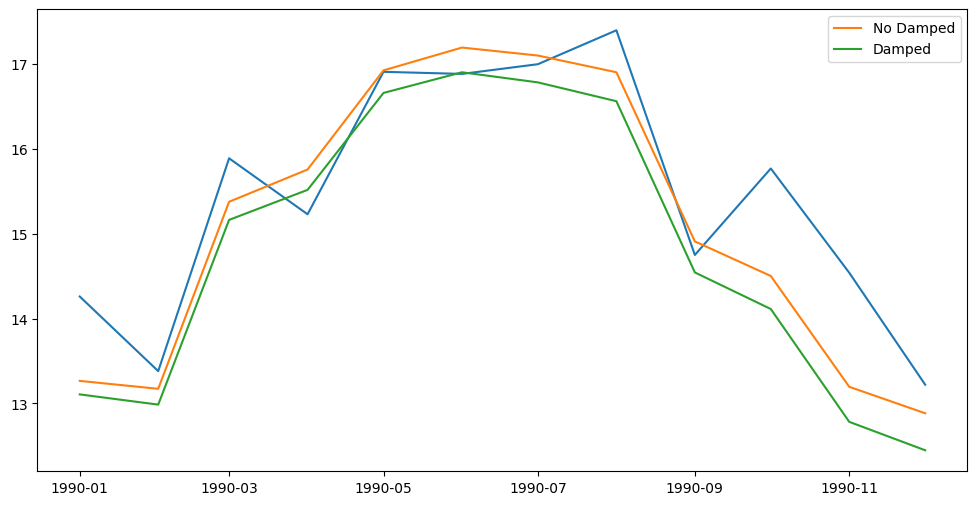

In [ ]:
y_train = y.iloc[:-12]
y_test = y.iloc[-12:]

fc_ets1 = ETSModel(y_train, error='add', trend='add', seasonal='add', seasonal_periods=12).fit().forecast(12)
fc_ets2 = ETSModel(y_train, error='add', trend='add', seasonal='add', seasonal_periods=12, damped_trend=True).fit().forecast(12)

print(accuracy(y_test, fc_ets1))
print(accuracy(y_test, fc_ets2))

plt.figure(figsize=(12, 6))
plt.plot(y_test)
plt.plot(fc_ets1, label='No Damped')
plt.plot(fc_ets2, label='Damped')
plt.legend()
plt.show()

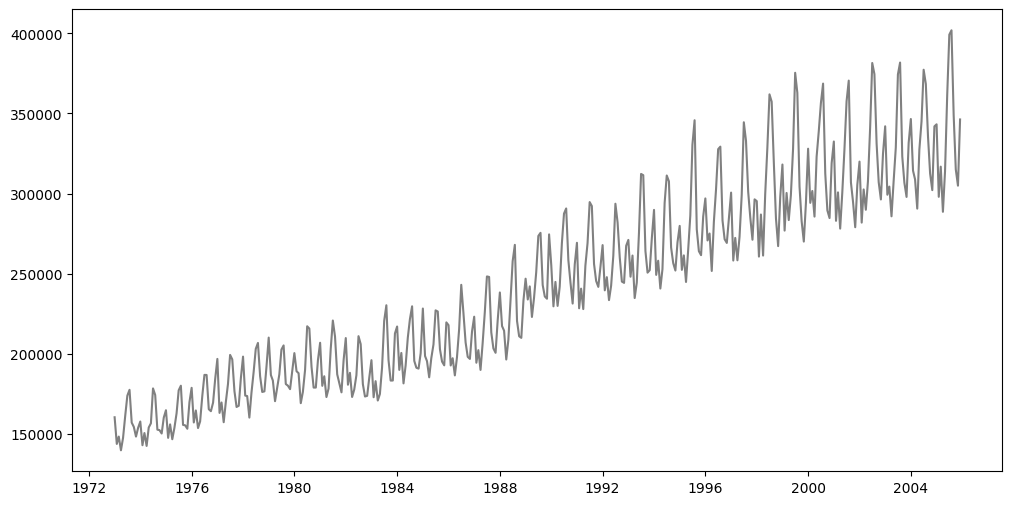

In [ ]:
# Series 4
elec = pd.read_csv('https://dxl-datasets.s3.us-east-1.amazonaws.com/mas640/misc/electricity.csv')
elec['date'] = pd.to_datetime(elec['date'])
elec = elec.set_index('date')
y = elec['electricity'].asfreq('MS')

plt.figure(figsize=(12, 6))
plt.plot(y, color='grey')
plt.show()

7034.874988314231


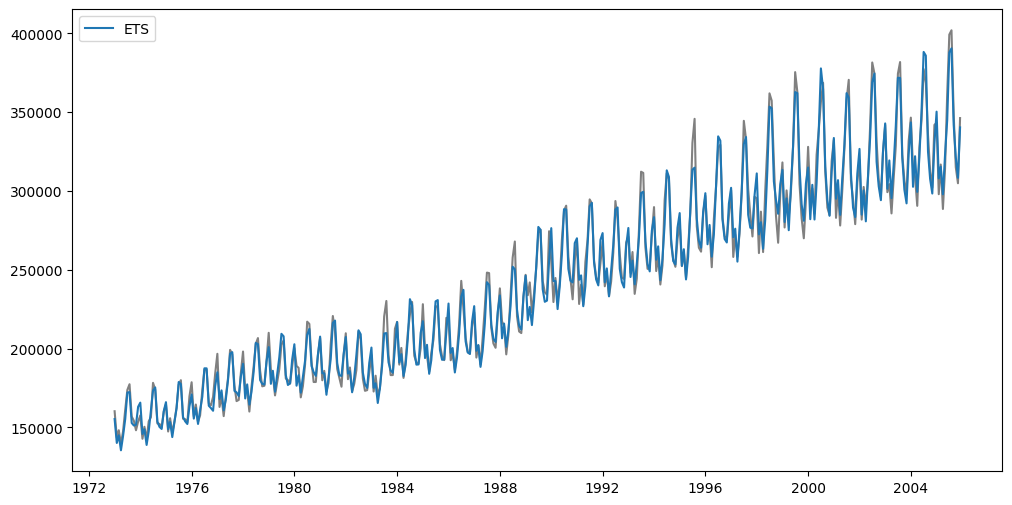

In [ ]:
m_ets = ETSModel(y, error='add', trend='add', seasonal='mul', seasonal_periods=12).fit()

plt.figure(figsize=(12, 6))
plt.plot(y, color='grey')
plt.plot(m_ets.fittedvalues, label='ETS')
plt.legend()
plt.show()

In [ ]:
y_train = y.iloc[:-12]
y_test = y.iloc[-12:]

fc_ets = ETSModel(y_train, error='add', trend='add', seasonal='mul', seasonal_periods=12).fit().forecast(12)

print(accuracy(y_test, fc_ets))


    MAE: 7557.851237407915
    RMSE: 8684.672614598909
    MAPE: 2.3339861389109164
  
None


In [ ]:
m = ARIMA(np.log(y), order=(1, 1, 1), seasonal_order=(0, 1, 1, 12)).fit()

print(m.summary())

                                    SARIMAX Results                                     
Dep. Variable:                      electricity   No. Observations:                  396
Model:             ARIMA(1, 1, 1)x(0, 1, 1, 12)   Log Likelihood                 846.177
Date:                          Tue, 10 Feb 2026   AIC                          -1684.354
Time:                                  03:20:19   BIC                          -1668.561
Sample:                              01-01-1973   HQIC                         -1678.089
                                   - 12-01-2005                                         
Covariance Type:                            opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4336      0.067      6.466      0.000       0.302       0.565
ma.L1         -0.8564      0.041    -20.979      0.

In [ ]:
fc_arima = np.exp(ARIMA(np.log(y_train), order=(1, 1, 1), seasonal_order=(0, 1, 1, 12)).fit().forecast(12))

print(accuracy(y_test, fc_arima))


    MAE: 8670.49190951359
    RMSE: 9341.279527954906
    MAPE: 2.644170131096782
  
None


In [ ]:
# Series 5
milk = pd.read_csv('https://dxl-datasets.s3.us-east-1.amazonaws.com/mas640/tsa/milk_production.csv')
milk['date'] = pd.to_datetime(milk['date'])
milk = milk.set_index('date')
y = milk['milk'].asfreq('MS')

In [ ]:
# Series 6
co2 = pd.read_csv('https://dxl-datasets.s3.us-east-1.amazonaws.com/mas640/tsa/co2.csv')
co2['date'] = pd.to_datetime(co2['date'])
co2 = co2.set_index('date')
y = co2['co2'].asfreq('MS')

plt.figure(figsize=(12,6))
plt.plot(y, color='grey')
plt.show()

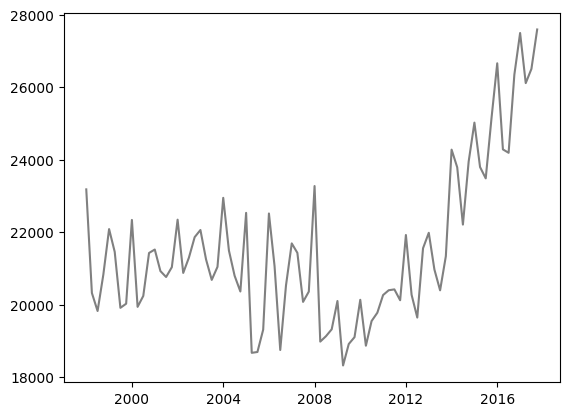

In [ ]:
# Series 7
tourism = pd.read_csv('https://dxl-datasets.s3.us-east-1.amazonaws.com/mas640/fppy/tourism.csv')
tourism = tourism.groupby('ds')['y'].sum().reset_index()
tourism['ds'] = pd.to_datetime(tourism['ds'])
tourism = tourism.set_index('ds')

y = tourism['y'].asfreq('QS')

plt.plot(y, color='grey')
plt.show()

In [ ]:
m1 = ETSModel(y, error='add', trend='add', seasonal='add', seasonal_periods=4, damped_trend=True).fit()
m2 = ETSModel(y, error='add', trend='add', seasonal='add', seasonal_periods=4, damped_trend=False).fit()

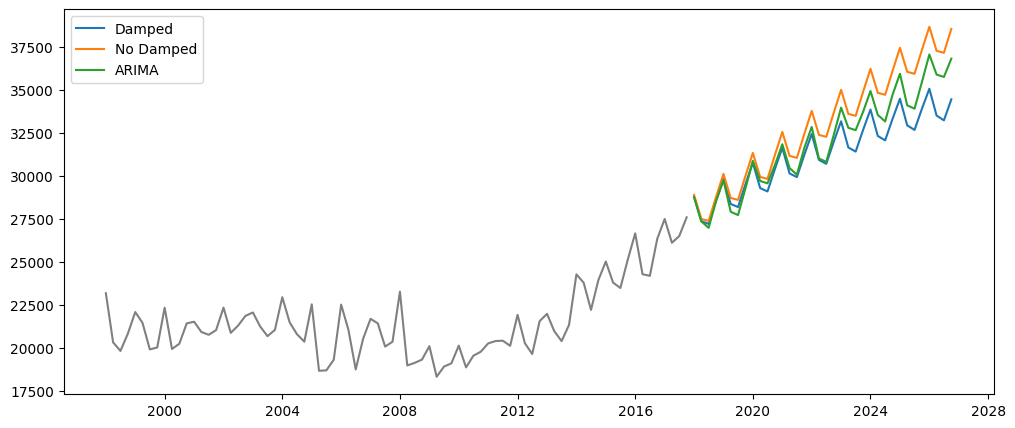

In [ ]:
fc1 = m1.forecast(36)
fc2 = m2.forecast(36)
fc3 = m.forecast(36)
plt.figure(figsize=(12, 5))
plt.plot(y, color='grey')
plt.plot(fc1, label='Damped')
plt.plot(fc2, label='No Damped')
plt.plot(fc3, label='ARIMA')
plt.legend()
plt.show()

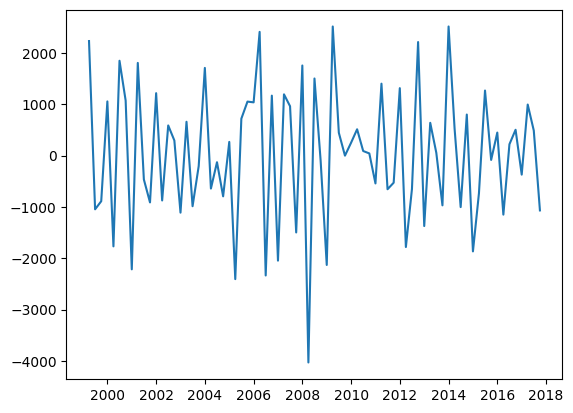

In [ ]:
plt.plot(y.diff().diff(4))

In [ ]:
m = ARIMA(y, order=(0, 1, 1), seasonal_order=(0, 1, 1, 4)).fit()

print(m.summary())

                                    SARIMAX Results                                    
Dep. Variable:                               y   No. Observations:                   80
Model:             ARIMA(0, 1, 1)x(0, 1, 1, 4)   Log Likelihood                -628.441
Date:                         Tue, 10 Feb 2026   AIC                           1262.882
Time:                                 11:08:17   BIC                           1269.834
Sample:                             01-01-1998   HQIC                          1265.658
                                  - 10-01-2017                                         
Covariance Type:                           opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.3486      0.073     -4.758      0.000      -0.492      -0.205
ma.S.L4       -0.3565      0.059     -6.074      0.000     

In [ ]:
def f_ets(y_train, h):
  y_hat = ETSModel(y_train, error='add', trend='add', seasonal='add', seasonal_periods=4, damped_trend=True).fit().forecast(h)
  return y_hat

def f_arima(y_train, h):
  y_hat = ARIMA(y_train, order=(0, 1, 1), seasonal_order=(0, 1, 1, 4)).fit().forecast(h)
  return y_hat